# Informações Gerais sobre o Conteúdo

---

### Uso de Inteligência Artificial
Este projeto utilizou ferramentas de IA como assistentes de coprodução. O objetivo principal deste documento é servir como uma fonte sólida de dados e material para estudos posteriores.

* **O que foi aprimorado por IA:** A otimização de trechos de código e o refinamento técnico das descrições dos métodos.
* **O que é de autoria própria:** Toda a formulação teórica, estruturação do projeto, arquitetura da API e a lógica de utilização foram planejadas e escritas pelo autor, assim como a elaboração da grande maioria dos códigos contidos aqui.

> **Resumo:** A IA funcionou como um copiloto para refinar o trabalho, mas a direção, a arquitetura e a execução principal são 100% humanas.

In [1]:
#Imports
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import defaultdict
import networkx as nx
import os
import pickle

from numpy.linalg import svd
from scipy.stats import chi2, norm, f
from IPython.display import display, Markdown
from numba import njit
import os 

try:
    from coppeliasim_zmqremoteapi_client import RemoteAPIClient 
    print("Biblioteca CoppeliasimZMQ já instalada")
except:
    print("Biblioteca CoppeliasimZMQ NÃO instalada")
    !pip install coppeliasim-zmqremoteapi-client
    from coppeliasim_zmqremoteapi_client import RemoteAPIClient 
    print("Biblitoeca instalada com sucesso!")

Biblioteca CoppeliasimZMQ já instalada


# Sobre a atividade

Aqui será desenvolvido um algorítmo para controle de um robô num ambiente desconhecido mediante a técnica Q-Learning, e finaliznado com a técnica TOSL-iBSR (True Online SARSA Informed-Based softmax regression)

- **Primeira etapa:** Desenvolvimento dos algorítmos básicos (Controle do robô)
- **Segunda etapa:** Cadeias de Markov (Teoria e implementações)
- **Terceira etapa:** Algorítmo de recompensa e Reinforced Learning
- **Quarta etapa:** Arquitetura TOSL-iBSR
- **Quinta Etapa:** Testes de rendimento para cada arquitetura

# 1. Primeira Etapa: Controle do Robô

## 1.1 Simulação no Coppelia

### Arquitetura do Sistema de Simulação

Este ecossistema utiliza a biblioteca de API Remota baseada em ZeroMQ (`coppeliasim_zmqremoteapi_client`) para estabelecer comunicação síncrona bidirecional com o simulador CoppeliaSim. A arquitetura divide-se logicamente em três componentes principais estruturados em Programação Orientada a Objetos (POO):

* **Classe `Simulation`**: Orquestrador genérico do loop de simulação. Gerencia a inicialização da conexão de rede, o relógio interno do motor de física e força o modo de execução síncrono.
* **Classe `Pioneer`**: Interface de baixo nível que abstrai o hardware do robô, lidando com a leitura de sensores reais do cenário e a atuação nos motores.
* **Classe `LyapunovController`**: Implementação matemática do algoritmo de controle de postura em malha fechada.

In [2]:
class Simulation:
    def __init__(self, max_time=30.0):
        self.max_time = max_time
        self.current_time = 0.0
        self.is_running = False
        
        # Initialize Remote API Client connection
        self.client = RemoteAPIClient()
        self.sim = self.client.getObject('sim')
        
        self.robot = None
        self.controller = None

    def setup(self):
        """Override to configure your scene objects."""
        pass

    def loop(self):
        """Override to program execution logic."""
        pass

    def stop(self):
        """Overrride to programa stop logic. """
        self.robot.stop()
        self.sim.stopSimulation()
        print(f"Simulation execution halted at {self.current_time:.2f} seconds.")
        
    def run(self):
        """Executes the synchronous simulation step loop inside CoppeliaSim."""
        self.setup()
        
        if self.robot is None:
            raise TypeError("Runtime Error: 'self.robot' must be initialized inside setup().")

        # Enable Synchronous stepping mode
        self.sim.setStepping(True)
        self.sim.startSimulation()
        self.is_running = True
        print("CoppeliaSim synchronous simulation initialized.")
        
        while self.is_running and self.current_time < self.max_time:
            # Get internal simulation clock time from engine
            self.current_time = self.sim.getSimulationTime()
            
            # Execute user-overridden logic loop
            self.loop()
            
            # Trigger physics step computation engine forward
            self.sim.step()

            #Add some timeout in the controller?
            
        # Stopping sequence execution
        self.stop()

## 1.2. Definindo robô Pionner

### O Robô Pioneer e a Abstração de Hardware

O robô que será utilizado nesta simulação é o **Pioneer**. Este modelo possui um anel com **16 sensores ultrassônicos** associados a ele, o que o torna uma plataforma altamente interessante para tarefas de navegação e percepção de ambiente. 

Para integrá-lo adequadamente, e considerando que estamos operando via API ZeroMQ do CoppeliaSim, será necessário definir uma classe dedicada (a classe `Pioneer`). Essa abordagem orientada a objetos nos permite abstrair toda a complexidade do controle de baixo nível, organizando a interação com o simulador em três frentes principais:

* **Percepção (Sensores):** Leitura contínua do array de ultrassons para medir a distância de possíveis obstáculos.
* **Cinemática (Atuação):** Conversão das velocidades de controle linear e angular em comandos de rotação individuais para os motores direito e esquerdo.
* **Localização (Pose):** Extração precisa da **pose** global do robô — ou seja, suas coordenadas espaciais cartesianas ($x, y$) e sua orientação/guiada ($\theta$) — em relação ao referencial absoluto do ambiente de simulação.

Essa estruturação torna o código limpo, modular e pronto para ser reutilizado facilmente em experimentos futuros.ros.

In [3]:
class Pioneer:
    def __init__(self, sim, robot_path='/PioneerP3DX'):
        """
        sim: The CoppeliaSim API instance object ('sim')
        robot_path: The base path of the Pioneer model in the scene hierarchy
        """
        self.sim = sim
        
        # Pioneer 3-DX physical specifications
        self.r = 0.0975  # Wheel radius (meters)
        self.L = 0.381   # Wheelbase track width (meters)

        # max 
        self.v_max = 1.6 # m/s
        self.w_max = 5.23 # rad/s
        
        # Fetch object handles from the CoppeliaSim scene hierarchy
        self.robot_handle = self.sim.getObject(robot_path)
        self.left_motor = self.sim.getObject(f"{robot_path}/leftMotor")
        self.right_motor = self.sim.getObject(f"{robot_path}/rightMotor")
        
        # Fetch handles for the 16 proximity sensors (sonars)
        # Note: Adjust the naming format string if your scene uses a different pattern
        self.sonar_handles = []
        for i in range(16):
            try:
                handle = self.sim.getObject(f"{robot_path}/sonar[{i}]")
                self.sonar_handles.append(handle)
            except Exception:
                # Fallback for alternative scene configurations (e.g., ultrasonicSensor[x])
                handle = self.sim.getObject(f"{robot_path}/ultrasonicSensor[{i}]")
                self.sonar_handles.append(handle)

    def get_pose(self):
        """
        Retrieves the absolute 2D pose (x, y, theta) from the simulator.
        Uses sim.handle_world (-1) as the reference frame.
        """
        position = self.sim.getObjectPosition(self.robot_handle, self.sim.handle_world)
        orientation = self.sim.getObjectOrientation(self.robot_handle, self.sim.handle_world)
        
        x = position[0]
        y = position[1]
        theta = orientation[2]  # Yaw angle around Z axis
        return np.array([x, y, theta])

    def send_commands(self, v, omega):
        """
        Inverse Kinematics: Computes wheel velocities and sends them to CoppeliaSim.
        """
        #clip velocities
        v = np.clip(v, -self.v_max, self.v_max)
        omega = np.clip(omega, -self.w_max, self.w_max)
        
        # Diferential equations
        w_r = (v + (omega * self.L) / 2.0) / self.r
        w_l = (v - (omega * self.L) / 2.0) / self.r

        
        self.sim.setJointTargetVelocity(self.left_motor, w_l)
        self.sim.setJointTargetVelocity(self.right_motor, w_r)

    def read_sonars(self):
        """
        Reads the 16 proximity sensors from the scene.
        Returns a NumPy array containing the detected distances.
        """
        distances = []
        for handle in self.sonar_handles:
            # sim.readProximitySensor returns: [result, distance, detectedPoint, detectedObjectHandle, detectedSurfaceNormalVector]
            result, distance, _, _, _ = self.sim.readProximitySensor(handle)
            
            if result > 0:
                distances.append(distance)
            else:
                distances.append(5.0)  # Max range default value if no obstacle detected
                
        return np.array(distances)

    def read_sonars_dict(self):
        """
        Read all sensor data and returns a dict with the correct information for each step.
        """
        distances = self.read_sonars()
        
        return {
            "front_left": distances[0:3],    # Sonars 0, 1, 2
            "front_center": distances[3:5],  # Sonars 3, 4 (Directly in the front center)
            "front_right": distances[5:8],   # Sonars 5, 6, 7
            "rear_right": distances[8:11],   # Sonars 8, 9, 10
            "rear_center": distances[11:13], # Sonars 11, 12
            "rear_left": distances[13:16]    # Sonars 13, 14, 15
        }

    def get_specific_sonars(self, indices):
        """
        Returns readings only from the requested sonars.
        Usage example: robot.get_specific_sonars([3, 4]) # Gets only the front sonars
        """
        distances = self.read_sonars() # Fetches all using your original method
        
        # Filters and returns a dictionary with only the desired indices
        resultado = {}
        for i in indices:
            if 0 <= i < 16:
                resultado[f"sonar_{i}"] = distances[i]
            else:
                print(f"Warning: Sonar {i} does not exist. Choose an index between 0 and 15.")
                
        return resultado
    
        
    def stop(self):
        """stops the robot Pionner"""
        self.send_commands(0,0)
        
# Class to a Dummy in the simulation
class Dummy:
    def __init__(self, sim, obj_path=None):
        """
        sim: The CoppeliaSim API instance object ('sim')
        robot_path: The base path of the Pioneer model in the scene hierarchy
        """
        self.sim = sim
        
        # Fetch object handles from the CoppeliaSim scene hierarchy
        self.obj_handle = self.sim.getObject(obj_path)
        
    def get_pose(self):
        """
        Retrieves the absolute 2D pose (x, y, theta) from the simulator.
        Uses sim.handle_world (-1) as the reference frame.
        """
        position = self.sim.getObjectPosition(self.obj_handle, self.sim.handle_world)
        orientation = self.sim.getObjectOrientation(self.obj_handle, self.sim.handle_world)
        
        x = position[0]
        y = position[1]
        theta = orientation[2]  # Yaw angle around Z axis
        return np.array([x, y, theta])

## 1.3. Controlador Diferencial (Não-holonômico)

### Controlador de Postura Baseado em Lyapunov

Devido às restrições não-holonômicas de robôs de acionamento diferencial (como o Pioneer, que não pode se deslocar lateralmente), o controle direto de posição em coordenadas cartesianas não é adequado e pode gerar instabilidade. Para contornar isso, implementamos um controlador de estabilização de postura baseado no método de Lyapunov, que transforma o problema para o espaço de coordenadas polares.

O controle calcula a atuação com base em um sistema de três erros geométricos:

* **$\rho$ (Erro de Distância)**: A distância euclidiana entre a posição atual do robô e a coordenada alvo.
* **$\alpha$ (Erro de Alinhamento)**: O ângulo entre a orientação atual do robô e a linha reta que o conecta ao objetivo.
* **$\beta$ (Erro de Orientação Final)**: A diferença entre o ângulo desejado de chegada e o vetor de aproximação.

#### Leis de Controle e Estabilidade

A partir da definição de uma função candidata de Lyapunov positiva definida, derivamos as seguintes leis de controle não-lineares para calcular a velocidade linear ($v$) e angular ($\omega$) a cada iteração:

$$v = k_\rho \cdot \rho \cdot \cos(\alpha)$$

$$\omega = k_\alpha \cdot \alpha + k_\rho \cdot \frac{\sin(\alpha)\cos(\alpha)}{\alpha} \cdot (\alpha + k_\beta \cdot \beta)$$

Para garantir matematicamente a estabilidade assintótica do sistema (ou seja, que o robô sempre convergirá para o alvo sem oscilar indefinidamente), os ganhos de sintonia do controlador devem respeitar rigorosamente as seguintes condições:

* $k_\rho > 0$
* $k_\alpha - k_\rho > 0$
* $k_\beta < 0$

In [4]:
class LyapunovController:
    def __init__(self, k_rho=0.6, k_alpha=2.0, k_beta=-0.3):
        self.k_rho = k_rho
        self.k_alpha = k_alpha
        self.k_beta = k_beta

    def calculate_control(self, current_pose, target_pose):
        """
        Vectorized tracking logic based on the 3 polar error system.
        """
        x, y, theta = current_pose
        x_g, y_g, theta_g = target_pose

        dx = x_g - x
        dy = y_g - y
        
        rho = np.hypot(dx, dy)
        
        # Dead-zone convergence logic
        if rho < 0.05:
            beta = theta_g - theta
            beta = np.arctan2(np.sin(beta), np.cos(beta))
            return 0.0, self.k_alpha * beta 

        gamma = np.arctan2(dy, dx)
        alpha = np.arctan2(np.sin(gamma - theta), np.cos(gamma - theta)) 
        beta = np.arctan2(np.sin(theta_g - gamma), np.cos(theta_g - gamma)) 

        # Control equations for forward navigation tracking
        if np.abs(alpha) <= np.pi / 2.0:
            v = self.k_rho * rho * np.cos(alpha)
            omega = self.k_alpha * alpha + self.k_rho * (np.sin(alpha) * np.cos(alpha) / alpha) * (alpha + self.k_beta * beta) if alpha != 0 else self.k_alpha * alpha
        else:
            # Backward navigation tracking modifications
            alpha_b = np.arctan2(np.sin(alpha + np.pi), np.cos(alpha + np.pi))
            beta_b = np.arctan2(np.sin(beta + np.pi), np.cos(beta + np.pi))
            v = -self.k_rho * rho * np.cos(alpha_b)
            omega = self.k_alpha * alpha_b + self.k_rho * (np.sin(alpha_b) * np.cos(alpha_b) / alpha_b) * (alpha_b + self.k_beta * beta_b) if alpha_b != 0 else self.k_alpha * alpha_b

        # Hardware safety clipping limits
        return np.clip(v, -0.7, 0.7), np.clip(omega, -1.2, 1.2)

## 1.4. Exemplo de utilização - Controle malha aberta.

**Exemplo 1** Malha aberta

In [8]:
class OpenLoopExperiment(Simulation):
    def setup(self):
        # Inicializa o robô Pioneer
        self.robot = Pioneer(self.sim, robot_path='/PioneerP3DX')
        print("Open-loop initialized: Moving forward.")

    def loop(self):
        # Definição das velocidades em malha aberta
        # v: velocidade linear em metros por segundo
        # omega: velocidade angular em radianos por segundo
        v = 0.3  
        omega = 1.0  
        
        # Envia o comando constante para os motores
        self.robot.send_commands(v, omega)
        
        # Imprime a telemetria atual para acompanhamento
        current_pose = self.robot.get_pose()
        print(f"Time: {self.current_time:.2f}s | Position: X={current_pose[0]:.2f}m, Y={current_pose[1]:.2f}m")


# ==============================================================================
# EXECUÇÃO
# ==============================================================================
if __name__ == "__main__":
    # Configurado para rodar a simulação por 5 segundos
    experiment = OpenLoopExperiment(max_time=10.0)
    experiment.run()

Open-loop initialized: Moving forward.
CoppeliaSim synchronous simulation initialized.
Time: 0.00s | Position: X=-15.05m, Y=2.92m
Time: 0.05s | Position: X=-15.05m, Y=2.93m
Time: 0.10s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15s | Position: X=-15.04m, Y=2.92m
Time: 0.15

KeyboardInterrupt: 

**Exemplo 2** Controlador em malha fechada

In [12]:
class ClosedLoopExperiment(Simulation):
    def setup(self):
        # Inicializa o robô Pioneer
        self.robot = Pioneer(self.sim, robot_path='/PioneerP3DX')
        self.controller = LyapunovController(k_rho=0.8, 
                                             k_alpha=2.0, 
                                             k_beta=-0.3)

        # Target Dummy
        self.Target=  Dummy(self.sim, obj_path='/target')
        print("Open-loop initialized: Moving forward.")

    def loop(self):
        actual_pose = self.robot.get_pose()
        #Pushing the pose of the target
        SP = self.Target.get_pose()
        # Controlador
        v_cmd, w_cmd = self.controller.calculate_control(actual_pose, SP)
        
        # Envia o comando constante para os motores
        self.robot.send_commands(v_cmd, w_cmd)
        
        # Imprime a telemetria atual para acompanhamento
        current_pose = self.robot.get_pose()
        #print(f"Time: {self.current_time:.2f}s | Position: X={current_pose[0]:.2f}m, Y={current_pose[1]:.2f}m")


# ==============================================================================
# EXECUÇÃO
# ==============================================================================
if __name__ == "__main__":
    simulation_time = 30 #seconds
    
    # Configurado para rodar a simulação por 5 segundos
    experiment = ClosedLoopExperiment(max_time=simulation_time)
    experiment.run()

Open-loop initialized: Moving forward.
CoppeliaSim synchronous simulation initialized.
Simulation execution halted at 30.00 seconds.


**Exemplo 3** - Leitura dos dados do radar

In [14]:
class ReadRadarData(Simulation):
    def setup(self):
        self.robot = Pioneer(self.sim, robot_path='/PioneerP3DX')

        # Distâncias máximas de tolerância
        self.F_max = 0.5  # Limite frontal
        self.L_max = 0.2  # Limite lateral (reduzido levemente para ele passar em portas)
        self.B_max = 0.2  # Limite traseiro

        self.v = 0.5 
        self.w = np.pi/2 
        
    def loop(self):
        actual_pose = self.robot.get_pose()
        sonar_data = self.robot.read_sonars_dict()
        
        # Puxando o mínimo de todas as 6 regiões do robô
        front_min = min(sonar_data["front_center"])
        left_min  = min(sonar_data["front_left"])
        right_min = min(sonar_data["front_right"])
        back_min  = min(sonar_data["rear_center"])
        b_left_min = min(sonar_data["rear_left"])
        b_right_min = min(sonar_data["rear_right"])
        
        # Criando o painel de flags (True = Perigo / Obstáculo detectado)
        _ff = front_min < self.F_max 
        _fl = left_min < self.L_max
        _fr = right_min < self.L_max
        _bf = back_min < self.B_max
        _bl = b_left_min < self.L_max
        _br = b_right_min < self.L_max
        
        # ÁRVORE DE DECISÃO POR FLAGS
        if _ff: 
            # CASO 1: Obstáculo na frente. Precisa parar de ir reto e decidir pra onde virar.
            if not _fr and not _fl: 
                # Frente bloqueada, mas ambos os lados livres -> Gira para a esquerda por padrão
                self.robot.send_commands(0, self.w) 
                
            elif not _fr and _fl: 
                # Objeto na esquerda -> Vira para a direita (omega negativo)
                self.robot.send_commands(0, -self.w)
                
            elif _fr and not _fl: 
                # Objeto na direita -> Vira para a esquerda (omega positivo)
                self.robot.send_commands(0, self.w)
                
            elif _fr and _fl: 
                # Preso na frente e nos lados. Precisa de manobra evasiva (ré).
                if not _bf: 
                    # A traseira está livre! Dá ré curvando para escapar.
                    self.robot.send_commands(-self.v, self.w)  
                else:
                    # Encurralado (Frente, Lados e Trás bloqueados). 
                    # Gira no próprio eixo para tentar achar uma saída fina.
                    self.robot.send_commands(0, self.w)
                    
        else:
            # CASO 2: Frente livre. Acelera, mas se protege de raspar nas laterais.
            if _fl and not _fr:
                # Passando muito perto de uma parede na ESQUERDA -> Curva leve p/ DIREITA
                self.robot.send_commands(self.v, -self.w / 2)
                
            elif _fr and not _fl:
                # Passando muito perto de uma parede na DIREITA -> Curva leve p/ ESQUERDA
                self.robot.send_commands(self.v, self.w / 2)
                
            else:
                # Tudo completamente livre
                self.robot.send_commands(self.v, 0.0) 


# ==============================================================================
# EXECUÇÃO
# ==============================================================================
if __name__ == "__main__":
    simulation_time = 10 
    
    experiment = ReadRadarData(max_time=simulation_time)
    experiment.run()

CoppeliaSim synchronous simulation initialized.
Simulation execution halted at 10.00 seconds.


**Exemplo 4** Utilizando as paredes como "molas", onde ele gira proporcional a distância até a parede.

### Teoria Matemática: Campos Potenciais Artificiais

**1. Força de Repulsão ($F_{rep}$)**
$$F_{rep} = \frac{1}{d + 0.01}$$
A força de repulsão é inversamente proporcional à distância $d$ do obstáculo, simulando um campo magnético que empurra o robô para longe.

**2. Velocidade Linear ($v$)**
$$v = \max(0, v_{base} - k_v \cdot F_{front})$$
A velocidade linear diminui conforme a repulsão frontal aumenta, fazendo o robô desacelerar suavemente ao se aproximar de uma parede.

**3. Velocidade Angular ($\omega$)**
$$\omega = k_w \cdot (F_{right} - F_{left})$$
A velocidade angular é calculada pela diferença das forças laterais, rotacionando o robô automaticamente em direção ao espaço mais livre.

In [15]:
class ReadRadarData(Simulation):
    def setup(self):
        self.robot = Pioneer(self.sim, robot_path='/PioneerP3DX')

        self.v_base = 0.8
        self.k_v = 0.15
        self.k_w = 0.4
        
    def loop(self):
        sonar_data = self.robot.read_sonars_dict()
        
        front_min = min(sonar_data["front_center"])
        left_min  = min(sonar_data["front_left"])
        right_min = min(sonar_data["front_right"])
        
        # Repulsão inversamente proporcional à distância
        rep_front = 1.0 / (front_min + 0.01)
        rep_left  = 1.0 / (left_min + 0.01)
        rep_right = 1.0 / (right_min + 0.01)
        
        # Cinemática baseada na diferença das forças
        v_cmd = max(0.0, self.v_base - (self.k_v * rep_front))
        w_cmd = self.k_w * (rep_right - rep_left)
        
        # Força giro extra em caso de beco sem saída (empate matemático)
        if front_min < 0.4 and abs(w_cmd) < 0.1:
            w_cmd = np.pi / 2 
            
        self.robot.send_commands(v_cmd, w_cmd)


# ==============================================================================
# EXECUÇÃO
# ==============================================================================
if __name__ == "__main__":
    experiment = ReadRadarData(max_time=30)
    experiment.run()

CoppeliaSim synchronous simulation initialized.
Simulation execution halted at 30.00 seconds.


# 2. Segunda Etapa: Cadeias de Markov

## 2.1. Cadeias de Markov

Trata-se de um processo estocástico discreto no tempo, denotado por $\{S_t\}_{t>0}$, que obedece à rigorosa **Propriedade de Markov**, no qual a informação atual é suficiente para definir o estado futuro, ou seja, o futuro depende apenas do estado presente. Matematicamente:
$$
    \mathbb{P}(S_{t+1} = s_{t+1} | S_t = s_t, S_{t-1}=s_{t-1},\dots, S_0 = s_0) = \mathbb{P}(S_{t+1}=s_{t+1}|S_t = s_t)
$$

Uma cadeia de Markov homogénea no tempo é completamente definida por uma tupla $(S,P)$, onde P é a matriz de transição de probabilidades. Cada elemento $P_{ij}$ representa a probabilidade de transitar do estado $i$ para o estado $j$:

$$
    P_{ij} = \mathbb{P}(S_{t+1}=j \mid S_t = i), \quad \text{onde} \quad \sum_{j\in S} P_{ij} = 1,
    \\
    \forall i \in S
$$


Sol 0.44 \ Chuva: 0.56


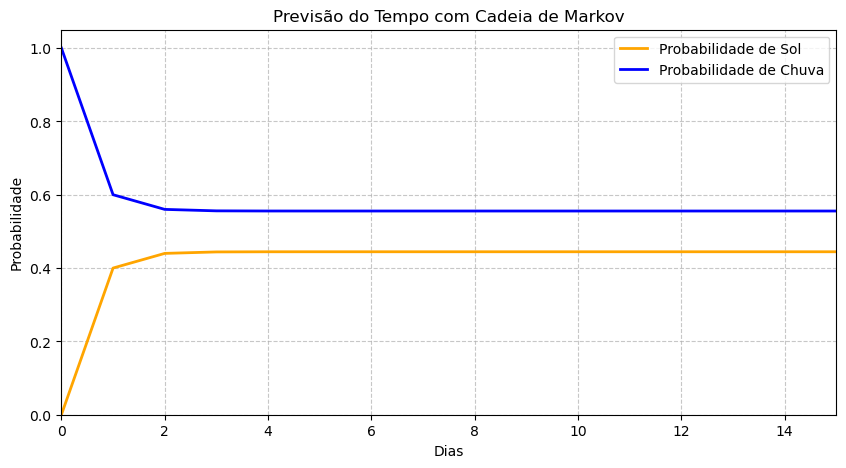

In [5]:
import numpy as np

# Matriz de Transição (P)
# Linhas = Estado Atual / Colunas = Próximo Estado
#           [Para Sol, Para Chuva]
P = np.array([[0.5,      0.5],    # De Sol
              [0.4,      0.6]])   # De Chuva

# Estado Inicial (Pi_0): Hoje está 100% Ensolarado
estado_atual = np.array([0, 1])

# Previsão para os próximos 3 dias
dias = 1000

# Listas para armazenar o histórico (começando com o dia 0)
prob_sol = [estado_atual[0]]
prob_chuva = [estado_atual[1]]

for dia in range(dias):
    # Multiplicação do vetor de estado pela matriz de transição
    estado_atual = np.dot(estado_atual, P)
    
    # Salva os resultados para plotar depois
    prob_sol.append(estado_atual[0])
    prob_chuva.append(estado_atual[1])

print(f"Sol {prob_sol[dias]:.2f} \ Chuva: {prob_chuva[dias]:.2f}")

# GERAÇÃO DO GRÁFICO
plt.figure(figsize=(10, 5))
plt.plot(prob_sol, label='Probabilidade de Sol', color='orange', linewidth=2)
plt.plot(prob_chuva, label='Probabilidade de Chuva', color='blue', linewidth=2)

plt.title('Previsão do Tempo com Cadeia de Markov')
plt.xlabel('Dias')
plt.ylabel('Probabilidade')
plt.ylim(0, 1.05)

# Limitando a visualização aos primeiros 15 dias para ver as curvas 
# (remova ou comente a linha abaixo para ver todos os 1000 dias)
plt.xlim(0, 15) 

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 2.1.1. Distribuição Marginal de Tempo

A distribuição do estado no tempo $t$ depende exclusivamente da distribuição inicial e da matriz de transição elevada à potência $t$.Seja $\nu_0$ o vetor de probabilidade inicial, onde $\nu_0(i) = P(X_0 = i)$. A distribuição de probabilidade do estado $X_t$ é dada por:$$\nu_t = \nu_0 P^t$$Onde $P^t$ é a matriz de transição de $t$ passos. Cada elemento $p_{ij}^{(t)}$ dessa matriz representa a probabilidade de transicionar do estado $i$ para o estado $j$ em exatamente $t$ passos.

In [6]:
# Célula de Código: Distribuição no Tempo t
import numpy as np

# 1. Definindo a matriz de transição P (Matriz Estocástica)
P = np.array([
    [0.7, 0.3, 0.0],
    [0.1, 0.8, 0.1],
    [0.2, 0.2, 0.6]
])

# 2. Vetor de distribuição inicial X_0 (ex: 100% de chance de começar no estado 0)
v0 = np.array([1.0, 0.0, 0.0])

# 3. Calculando a distribuição após t passos (ex: t = 5)
t = 5
Pt = np.linalg.matrix_power(P, t)
vt = v0 @ Pt

print(f"Matriz P^{t}:\n{Pt}\n")
print(f"Distribuição de X_{t}: {vt}")

Matriz P^5:
[[0.32218 0.56835 0.10947]
 [0.26243 0.58461 0.15296]
 [0.30592 0.52486 0.16922]]

Distribuição de X_5: [0.32218 0.56835 0.10947]


### Probabilidade de Trajetória

A probabilidade de trajetória (ou probabilidade de um caminho) define a chance de a Cadeia de Markov seguir uma sequência específica e exata de estados ao longo do tempo. 

Graças à **Propriedade de Markov**, o estado futuro depende exclusivamente do estado imediatamente anterior. Isso nos permite simplificar a probabilidade conjunta de uma sequência inteira de eventos, transformando-a em um produto multiplicativo simples entre a distribuição inicial e as probabilidades de transição passo a passo.

Formalmente, a probabilidade de a cadeia realizar a trajetória exata $X_0 = i_0, X_1 = i_1, X_2 = i_2, \dots, X_t = i_t$ é dada por:

$$P(X_0 = i_0, X_1 = i_1, \dots, X_t = i_t) = P(X_0 = i_0) \prod_{k=1}^{t} P(X_k = i_k \mid X_{k-1} = i_{k-1})$$

Substituindo pela notação padrão do vetor de distribuição inicial $\nu_0$ e dos elementos da matriz de transição $p_{ij}$, a equação assume a seguinte forma:

$$P(X_0 = i_0, X_1 = i_1, \dots, X_t = i_t) = \nu_0(i_0) \cdot p_{i_0 i_1} \cdot p_{i_1 i_2} \cdots p_{i_{t-1} i_t}$$

> ⚠️ **Atenção ao Ponto de Partida:** Se o enunciado ou o problema garantir que a cadeia começou obrigatoriamente em um estado fixo $i_0$, o termo da distribuição inicial $P(X_0 = i_0)$ assume o valor $1$. A probabilidade do caminho passa a ser estritamente o produto das transições.

### 2.1.2. Estrutura de Classe

Os estados de uma Cadeia de Markov podem ser classificados geometricamente e topologicamente com base na capacidade de transição entre si. Essa análise estrutural facilita a decomposição de cadeias complexas em blocos menores.

* **Acessibilidade ($i \rightarrow j$):** Um estado $j$ é dito acessível a partir de um estado $i$ se a probabilidade de transitar de $i$ para $j$ em algum momento for estritamente positiva. Formalmente:
  $$\exists n \ge 0 \quad \text{tal que} \quad p_{ij}^{(n)} > 0$$

* **Comunicação ($i \leftrightarrow j$):** Se o estado $j$ é acessível a partir de $i$ ($i \rightarrow j$) e o estado $i$ também é acessível a partir de $j$ ($j \rightarrow i$), dizemos que os estados **se comunicam**.

* **Classes de Comunicação:** A relação de comunicação ($\leftrightarrow$) é uma relação de equivalência (pois é reflexiva, simétrica e transitiva). Portanto, ela particiona o espaço de estados em **classes de equivalência disjuntas**. Estados dentro de uma mesma classe comunicam-se entre si, mas não se comunicam com estados de outras classes.

    * **Classes Fechadas** quando, após entrar, é impossível sair dessa classe. Ou seja:
      $$P(j \notin A | i \in A) =0  $$
* **Irredutibilidade:** Uma cadeia de Markov é dita **irredutível** se o seu espaço de estados possui **apenas uma** classe de comunicação. Em termos práticos, significa que é possível partir de qualquer estado e atingir qualquer outro estado da cadeia.

* **Recorrência vs. Transitoriedade:**
  * **Estado Recorrente:** Um estado $i$ é recorrente se, ao partir dele, a probabilidade de retornar a ele em algum momento no futuro é igual a $1$. Em cadeias finitas, se uma classe é *fechada* (impossível sair dela após entrar), todos os seus estados são recorrentes.
  * **Estado Transiente:** Um estado $i$ é transiente se a probabilidade de retornar a ele é menor que $1$. Existe uma chance real de a cadeia abandonar esse estado e nunca mais voltar.

> 💡 **Regra de Ouro:** Propriedades como *recorrência*, *transitoriedade* e *período* são **propriedades de classe**. Se um estado de uma classe possui essa característica, todos os outros estados da mesma classe obrigatoriamente também a possuem.

In [8]:
# Célula de Código: Identificando Classes de Comunicação
import networkx as nx
import numpy as np

# Matriz de transição onde:
P_classe = np.array([
    [0.7, 0.3, 0.0],  # Estado 0 (se comunica com 1)
    [0.2, 0.5, 0.3],  # Estado 1 -> Consegue ir para o Estado 2!
    [0.0, 0.0, 1.0]   # Estado 2 -> Não volta para ninguém (Absorvente)
])

# Criando um dígrafo (Grafo Direcionado) a partir da matriz
G = nx.from_numpy_array(P_classe, create_using=nx.DiGraph)

# As classes de comunicação equivalem aos Componentes Fortemente Conectados (SCC)
classes = list(nx.strongly_connected_components(G))

print("Estrutura de Classes Encontrada:")
for i, classe in enumerate(classes):
    print(f"Classe {i+1}: Estados {list(classe)}")

Estrutura de Classes Encontrada:
Classe 1: Estados [2]
Classe 2: Estados [0, 1]


### 2.1.3. Probabilidades de atingimento

Seja $A$ um subconjunto de estados do espaço amostral. A probabilidade de atingimento (ou colisão) a partir de um estado inicial $i$ é a probabilidade de que a cadeia eventualmente entre no conjunto $A$:$$h_i^A = P(\tau_A < \infty \mid X_0 = i)$$Onde $\tau_A = \min \{ t \ge 0 : X_t \in A \}$ é o primeiro tempo de passagem. O vetor de probabilidades $h^A$ é a solução mínima não-negativa para o sistema de equações:$$h_i^A = 1 \quad \text{para } i \in A$$$$h_i^A = \sum_{j} p_{ij} h_j^A \quad \text{para } i \notin A$$

In [10]:
# Matriz de transição: 0 e 1 são transientes, 2 e 3 são absorventes (conjunto A)
# Queremos descobrir a probabilidade de ser absorvido pelo estado 3
P_hit = np.array([
    [0.5, 0.2, 0.1, 0.2],  # Estado 0
    [0.1, 0.6, 0.2, 0.1],  # Estado 1
    [0.0, 0.0, 1.0, 0.0],  # Estado 2 (Absorvente)
    [0.0, 0.0, 0.0, 1.0]   # Estado 3 (Absorvente - Nosso Alvo 'A')
])

# Para os estados transientes (0 e 1), resolvemos o sistema: (I - Q) * h = R
# Onde Q é a submatriz transiente e R é a transição dos transientes para o alvo
Q = P_hit[0:2, 0:2]
R = P_hit[0:2, 3] # Coluna do estado alvo 3
I = np.eye(2)

# Resolvendo o sistema linear
h_transientes = np.linalg.solve(I - Q, R)

print(f"Probabilidade de atingir o Estado 3:")
print(f"Partindo do Estado 0: {h_transientes[0]:.4f}")
print(f"Partindo do Estado 1: {h_transientes[1]:.4f}")

Probabilidade de atingir o Estado 3:
Partindo do Estado 0: 0.5556
Partindo do Estado 1: 0.3889


### Tempo Esperado de Atingimento (Mean Hitting Time)

Seja $A$ un subconjunto de estados do espaço amostral. O tempo esperado de atingimento $k_i^A$ a partir de um estado inicial $i$ é o número médio de passos (tempo esperado) que a cadeia leva para entrar no conjunto $A$ pela primeira vez.

Formalmente, definimos o primeiro tempo de passagem como 

$$\tau_A = \min \{ t \ge 0 : X_t \in A \}$$

O tempo esperado 

$$k_i^A = E[\tau_A \mid X_0 = i]$$ 

é a solução mínima não-negativa para o seguinte sistema de equações lineares:

$$k_i^A = 0 \quad \text{para } i \in A$$
$$k_i^A = 1 + \sum_{j} p_{ij} k_j^A \quad \text{para } i \notin A$$

#### Intuição da Fórmula:
* Se a cadeia já começa dentro do conjunto alvo ($i \in A$), o tempo para atingi-lo é zero ($k_i^A = 0$).
* Se a cadeia começa fora ($i \notin A$), ela gasta obrigatoriamente $1$ passo de tempo para transicionar para um estado $j$ (com probabilidade $p_{ij}$). A partir desse novo estado $j$, o tempo restante esperado será $k_j^A$.

Em forma matricial, para os estados que não pertencem a $A$, o sistema pode ser resolvido como:
$$(I - Q)k = \mathbf{1}$$

Onde $Q$ é a submatriz de transição apenas entre os estados fora de $A$, $I$ é a matriz identidade correspondente e $\mathbf{1}$ é um vetor de uns.

In [11]:
# =====================================================================
# 1. DEFINIÇÃO DA CADEIA DE MARKOV
# =====================================================================
# Estados: 0 (Muito Sol), 1 (Nublado), 2 (Chuva Interminável - Nosso Alvo Absorvente 'A')
# Queremos saber quantos dias (passos) demora para começar a chover (atingir o Estado 2)

P = np.array([
    [0.6, 0.3, 0.1],  # Estado 0
    [0.2, 0.5, 0.3],  # Estado 1
    [0.0, 0.0, 1.0]   # Estado 2 (Alvo/Absorvente)
])

print("--- ABORDAGEM MATEMÁTICA (ANALÍTICA) ---")

# Isolamos a submatriz Q (apenas as linhas e colunas dos estados transientes: 0 e 1)
Q = P[0:2, 0:2]
I = np.eye(Q.shape[0])
ones = np.ones(Q.shape[0])

# Resolvendo o sistema linear: (I - Q) * k = 1
# Isso calcula analiticamente o tempo médio de passos
k_teorico = np.linalg.solve(I - Q, ones)

print(f"Tempo médio partindo do Estado 0 (Sol): {k_teorico[0]:.2f} dias")
print(f"Tempo médio partindo do Estado 1 (Nublado): {k_teorico[1]:.2f} dias\n")


# =====================================================================
# 2. SIMULAÇÃO DE MONTE CARLO (VALIDAÇÃO PRÁTICA)
# =====================================================================
print("--- ABORDAGEM POR SIMULAÇÃO (MONTE CARLO) ---")

def simular_tempo_atingimento(estado_inicial, alvo=2):
    estado_atual = estado_inicial
    passos = 0
    
    # Roda o loop até a cadeia colidir com o estado alvo
    while estado_atual != alvo:
        # Escolhe o próximo estado com base nas probabilidades da linha do estado atual
        estado_atual = np.random.choice([0, 1, 2], p=P[estado_atual])
        passos += 1
        
    return passos

# Executa a simulação 50.000 vezes para cada estado inicial para obter uma boa média
n_simulacoes = 50000

for estado_id in [0, 1]:
    tempos_obtidos = [simular_tempo_atingimento(estado_inicial=estado_id) for _ in range(n_simulacoes)]
    media_simulada = np.mean(tempos_obtidos)
    print(f"Média simulada após {n_simulacoes} testes partindo do Estado {estado_id}: {media_simulada:.2f} dias")

--- ABORDAGEM MATEMÁTICA (ANALÍTICA) ---
Tempo médio partindo do Estado 0 (Sol): 5.71 dias
Tempo médio partindo do Estado 1 (Nublado): 4.29 dias

--- ABORDAGEM POR SIMULAÇÃO (MONTE CARLO) ---
Média simulada após 50000 testes partindo do Estado 0: 5.71 dias
Média simulada após 50000 testes partindo do Estado 1: 4.30 dias


## 2.2. Processos de Decisão de Markov (MDP)

Para modelar o controlo autónomo, estende-se a Cadeia de Markov para permitir a intervenção de um agente, resultando no **Processo de Decisão de Markov (MDP)**. O MDP é formalizado pela tupla $ \mathcal{M} = (\mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma) $

Onde:
- $\mathcal{S}$: Espaço de estados do agente, ou seja, as possíveis configurações que ele pode estar;
- $\mathcal{A}$: Espaço das ações que o agente pode realizar;
- $\mathcal{P}$: Matriz de Transição de probabilidades;
- $\mathcal{R}$: Função de recompensa $\mathcal{R}(s,a,s^´)$;
- $\mathcal{\gamma}$: Desconto Temporal, $\mathcal{\gamma} \in [0,1]$.

O objetido do agente é encontrar uma política ótima $\pi^* (a|s)$ que maximize a esperança do Retorno Descontado $G_t$:

$$
    G_t = \sum_{k=0}^{\infty}\gamma^k R_{t+k+1}
$$


In [22]:
class ProcessoDecisaoMarkov:
    def __init__(self, espaco_estados, espaco_acoes, matriz_transicao, matriz_recompensa):
        """
        Inicializa o MDP.
        :param espaco_estados: Lista de estados (ex: ['Alta', 'Baixa'])
        :param espaco_acoes: Lista de ações (ex: ['Limpar', 'Recarregar'])
        :param matriz_transicao: Dicionário P[estado][acao] = [probabilidades do prox estado]
        :param matriz_recompensa: Dicionário R[estado][acao] = valor da recompensa
        """
        self.estados = espaco_estados
        self.acoes = espaco_acoes
        self.P = matriz_transicao
        self.R = matriz_recompensa
        
    def dar_passo(self, estado_atual, acao):
        """
        Executa uma ação a partir de um estado e retorna o próximo estado e a recompensa.
        """
        # Pega a lista de probabilidades para o (estado_atual, acao)
        probabilidades = self.P[estado_atual][acao]
        
        # Sorteia o próximo estado com base na ação escolhida
        estado_novo = np.random.choice(self.estados, p=probabilidades)
        
        # Coleta a recompensa correspondente
        recompensa = self.R[estado_atual][acao]
        
        return estado_novo, recompensa

**Exemplo - Robô recarregador**

Este código simula um Processo de Decisão de Markov (MDP) estruturando as regras de um ambiente estático (transições) e seu sistema de pontuação (recompensas) para um robô.

O agente possui dois estados de bateria (alta/baixa) e duas ações possíveis (limpar/recarregar).
A simulação aplica uma política estritamente aleatória, onde o robô sorteia N ações seguidas de forma "cega", sem considerar o seu nível de bateria no momento.

Um loop executa cada passo dessa política no ambiente, atualizando o status do robô e acumulando a pontuação gerada por cada escolha.
Ao final, o código exibe o saldo total, demonstrando as consequências práticas e matemáticas de tomar decisões sem uma estratégia de aprendizado.

In [38]:
# 1. Definimos Estados e Ações do Robô
estados_robo = ['Bateria Alta', 'Bateria Baixa']
acoes_robo = ['Limpar', 'Recarregar']

# 2. Transições: P[estado][acao] = [Prob(Bateria Alta), Prob(Bateria Baixa)]
transicoes = { #Representa o ambiente, estático
    'Bateria Alta': {
        'Limpar': [0.8, 0.2],     # 80% de chance de continuar Alta, 20% de cair para Baixa
        'Recarregar': [1.0, 0.0]  # Fica 100% no estado Alta
    },
    'Bateria Baixa': {
        'Limpar': [0.0, 1.0],     # Continua com a bateria baixa (risco de quebrar!)
        'Recarregar': [1.0, 0.0]  # 100% de chance de voltar para Bateria Alta
    }
}

# 3. Recompensas: R[estado][acao] = pontos ganhos
recompensas = {
    'Bateria Alta': {
        'Limpar': 10,     # Fazer o trabalho rende pontos
        'Recarregar': 0   # Desperdício de tempo recarregar o que já está cheio
    },
    'Bateria Baixa': {
        'Limpar': -50,    # Punição severa: forçou o motor sem bateria
        'Recarregar': 5   # Decisão sensata, ganha uns pontinhos
    }
}

# 4. Inicializamos o MDP
mdp_robo = ProcessoDecisaoMarkov(estados_robo, acoes_robo, transicoes, recompensas)

# 5. Simulando um pequeno episódio com uma "Política Aleatória"
estado_atual = 'Bateria Alta'
pontuacao_total = 0

print("--- Iniciando Turno de Trabalho ---")
print(f"Estado inicial: {estado_atual}\n")

# Definimos a quantidade de passos desejada
n_passos = 12

# O numpy escolhe aleatoriamente 12 ações dentro da nossa lista 'acoes_robo' 
# Aqui está determinada a política pi(s,a), porém, estática, sem uma lógica por trás, nem aprendizado.
acoes_escolhidas = np.random.choice(acoes_robo, size=n_passos)

# O restante do loop continua igual!
for passo, acao in enumerate(acoes_escolhidas, 1):
    estado_novo, rec = mdp_robo.dar_passo(estado_atual, acao)
    pontuacao_total += rec
    
    # Adicionei um formatação no {passo:<2} para alinhar os números de dois dígitos
    print(f"Passo {passo:<2} | Estado Atual: {estado_atual:<14} | Ação escolhida: {acao:<10} | Recompensa: {rec:>3} | Próximo Estado: {estado_novo}")
    
    estado_atual = estado_novo
    
print(f"\nPontuação Final do Robô: {pontuacao_total}")

--- Iniciando Turno de Trabalho ---
Estado inicial: Bateria Alta

Passo 1  | Estado Atual: Bateria Alta   | Ação escolhida: Limpar     | Recompensa:  10 | Próximo Estado: Bateria Alta
Passo 2  | Estado Atual: Bateria Alta   | Ação escolhida: Limpar     | Recompensa:  10 | Próximo Estado: Bateria Alta
Passo 3  | Estado Atual: Bateria Alta   | Ação escolhida: Recarregar | Recompensa:   0 | Próximo Estado: Bateria Alta
Passo 4  | Estado Atual: Bateria Alta   | Ação escolhida: Limpar     | Recompensa:  10 | Próximo Estado: Bateria Alta
Passo 5  | Estado Atual: Bateria Alta   | Ação escolhida: Recarregar | Recompensa:   0 | Próximo Estado: Bateria Alta
Passo 6  | Estado Atual: Bateria Alta   | Ação escolhida: Limpar     | Recompensa:  10 | Próximo Estado: Bateria Alta
Passo 7  | Estado Atual: Bateria Alta   | Ação escolhida: Recarregar | Recompensa:   0 | Próximo Estado: Bateria Alta
Passo 8  | Estado Atual: Bateria Alta   | Ação escolhida: Recarregar | Recompensa:   0 | Próximo Estado: Bat

## 2.2.1. Função Valor (V) e Função Valor de Ação (Q)

A **Função Valor de Estado** $V^\pi(s)$ define o ganho esperado partindo do estado $s$ sob a política $\pi$:
\begin{equation}
V^\pi(s) = \mathbb{E}_\pi [G_t \mid S_t = s]
\end{equation}
A **Função Valor de Ação** $Q^\pi(s,a)$ avalia a qualidade de tomar a ação $a$ no estado $s$:
\begin{equation}
Q^\pi(s,a) = \mathbb{E}_\pi \left[ \sum_{k=0}^{\infty} \gamma^k R_{t+k+1} \mid S_t = s, A_t = a \right]
\end{equation}

A **Equação de Otimização de Bellman** estabelece que o valor ótimo de um estado-ação é a recompensa imediata somada ao valor descontado do melhor estado-ação subsequente possível:
\begin{equation}
Q^*(s, a) = \sum_{s' \in \mathcal{S}} \mathcal{P}_{ss'}^a \left( \mathcal{R}_{ss'}^a + \gamma \max_{a'} Q^*(s', a') \right)
\end{equation}

In [40]:
num_estados = 2
num_acoes = 2
gamma = 0.9

#Transição de estados
P = np.array([
    # ESTADO ATUAL 0
    [ 
      [0.2, 0.8], # Se escolheu Ação 0 -> [Chance ir pro Estado 0, Chance ir pro Estado 1]
      [0.9, 0.1]  # Se escolheu Ação 1 -> [Chance ir pro Estado 0, Chance ir pro Estado 1]
    ],  
    
    # ESTADO ATUAL 1
    [ 
      [0.1, 0.9], # Se escolheu Ação 0 -> [Chance ir pro Estado 0, Chance ir pro Estado 1]
      [0.8, 0.2]  # Se escolheu Ação 1 -> [Chance ir pro Estado 0, Chance ir pro Estado 1]
    ]   
])

#Recompensas
R = np.array([
    # ESTADO ATUAL 0
    [ 
      [-1.0, 5.0], # Ação 0 -> [Pontos se cair no Estado 0, Pontos se cair no Estado 1]
      [ 0.0,-1.0]  # Ação 1 -> [Pontos se cair no Estado 0, Pontos se cair no Estado 1]
    ],
    
    # ESTADO ATUAL 1
    [ 
      [ 5.0, 10.0], # Ação 0 -> [Pontos se cair no Estado 0, Pontos se cair no Estado 1]
      [-5.0,  0.0]  # Ação 1 -> [Pontos se cair no Estado 0, Pontos se cair no Estado 1]
    ]
])

num_episodios = 10000  # Quantidade de vezes que vamos simular para tirar a média
passos_por_episodio = 20 # Aumentado para 20 para o desconto gama^t convergir melhor

# ==========================================
# Calculando V(s=0)
# ==========================================
soma_Gt_V = 0.0
estado_inicial = 1

for _ in range(num_episodios):
    estado = estado_inicial
    G_t = 0.0
    for t in range(passos_por_episodio):
        acao = np.random.choice(num_acoes) # Política Aleatória (50% pra cada)
        prox_estado = np.random.choice(num_estados, p=P[estado, acao])
        recompensa = R[estado, acao, prox_estado]
        
        G_t += (gamma ** t) * recompensa
        estado = prox_estado
        
    soma_Gt_V += G_t

V_s0 = soma_Gt_V / num_episodios
print(f"V(s=0) aproximado por Monte Carlo: {V_s0:.2f}")

# ==========================================
# Calculando Q(s=0, a=1)
# ==========================================
soma_Gt_Q = 0.0

for _ in range(num_episodios):
    estado = 0
    G_t = 0.0
    for t in range(passos_por_episodio):
        # O segredo do Q: no primeiro passo (t=0), FORÇAMOS a ação a=1
        if t == 0:
            acao = 1
        else:
            acao = np.random.choice(num_acoes) # Nos passos seguintes, segue a política aleatória
            
        prox_estado = np.random.choice(num_estados, p=P[estado, acao])
        recompensa = R[estado, acao, prox_estado]
        
        G_t += (gamma ** t) * recompensa
        estado = prox_estado
        
    soma_Gt_Q += G_t

Q_s0_a1 = soma_Gt_Q / num_episodios
print(f"Q(s=0, a=1) aproximado por Monte Carlo: {Q_s0_a1:.2f}")

V(s=0) aproximado por Monte Carlo: 20.89
Q(s=0, a=1) aproximado por Monte Carlo: 17.33


# 3. Terceira Etapa: Base teórica e métodos clássicos

## 3.1. Q-learning

O algoritmo **Q-Learning** contorna o desconhecimento das probabilidades de transição $\mathcal{P}_{ss'}^a$ utilizando amostras reais da interação. A matriz $Q$ é iterativamente atualizada através do Erro de Diferença Temporal (Erro TD, $\delta_t$):
\begin{equation}
\delta_t = \underbrace{R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a')}_{\text{Alvo TD}} - \underbrace{Q(S_t, A_t)}_{\text{Estimativa Atual}}
\end{equation}
\begin{equation}
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \delta_t
\end{equation}

In [7]:
class AgenteQLearning:
    def __init__(self, num_acoes, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.num_acoes = num_acoes
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        # Tabela Q: Dicionário que inicializa com zeros para estados novos
        self.Q = defaultdict(lambda: np.zeros(num_acoes))
        
    def escolher_acao(self, estado):
        """Política Épsilon-Gananciosa"""
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.num_acoes) # Exploração
        return np.argmax(self.Q[estado])             # Explotação
        
    def atualizar(self, estado, acao, recompensa, proximo_estado, done):
        """Atualiza a matriz Q usando o Erro TD do Q-Learning (Off-Policy)"""
        if done:
            alvo_td = recompensa
        else:
            melhor_proxima_acao = np.argmax(self.Q[proximo_estado])
            alvo_td = recompensa + self.gamma * self.Q[proximo_estado][melhor_proxima_acao]
            
        erro_td = alvo_td - self.Q[estado][acao]
        self.Q[estado][acao] += self.alpha * erro_td

## 3.2. True Online SARSA ($\lambda$) com Traços de Elegibilidade

O SARSA($\lambda$) acelera o aprendizado propagando a recompensa para as ações passadas através de uma memória de curto prazo chamada Traço de Elegibilidade, representada pela matriz $E(s, a)$ inicializada com zeros. A cada passo, o traço do par atual é ativado e calcula-se o erro da Diferença Temporal $\delta$:

$$\delta = R + \gamma Q(S', A') - Q(S, A)$$

Em seguida, atualizamos a tabela $Q$ de *todos* os pares estado-ação proporcionalmente a esse erro e ao seu respectivo traço. Imediatamente após a atualização, todos os traços sofrem um decaimento exponencial controlado pelos fatores $\gamma$ e $\lambda$:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \delta E(s, a)$$

$$E(s, a) \leftarrow \gamma \lambda E(s, a)$$

In [8]:
#SARSA
class AgenteSARSA:
    def __init__(self, num_acoes, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.num_acoes = num_acoes
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = defaultdict(lambda: np.zeros(num_acoes))
        
    def escolher_acao(self, estado):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.num_acoes)
        return np.argmax(self.Q[estado])
        
    def atualizar(self, estado, acao, recompensa, proximo_estado, proxima_acao, done):
        if done:
            alvo_td = recompensa
        else:
            alvo_td = recompensa + self.gamma * self.Q[proximo_estado][proxima_acao]
            
        erro_td = alvo_td - self.Q[estado][acao]
        self.Q[estado][acao] += self.alpha * erro_td


#SARSA Lambda
class AgenteSARSALambda:
    def __init__(self, num_acoes, alpha=0.1, gamma=0.9, epsilon=0.1, lambd=0.8):
        self.num_acoes = num_acoes
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.lambd = lambd  # Parâmetro de decaimento do traço
        self.Q = defaultdict(lambda: np.zeros(num_acoes))
        self.E = defaultdict(lambda: np.zeros(num_acoes)) # Matriz de Traços
        
    def escolher_acao(self, estado):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.num_acoes)
        return np.argmax(self.Q[estado])
        
    def limpar_tracos(self):
        """Deve ser chamado no início de cada novo episódio"""
        self.E.clear()
        
    def atualizar(self, estado, acao, recompensa, proximo_estado, proxima_acao, done):
        # 1. Calcula o Erro TD
        if done:
            alvo_td = recompensa
        else:
            alvo_td = recompensa + self.gamma * self.Q[proximo_estado][proxima_acao]
            
        erro_td = alvo_td - self.Q[estado][acao]
        
        # 2. Incrementa o traço de elegibilidade para o estado-ação atual
        # Usando traço de substituição (Replacing Trace) para estabilidade
        self.E[estado][acao] = 1.0 
        
        # 3. Atualiza todos os Qs e decai todos os Traços
        for s in list(self.Q.keys()):
            for a in range(self.num_acoes):
                # Se o traço for maior que zero, aplica a atualização
                if self.E[s][a] > 0:
                    self.Q[s][a] += self.alpha * erro_td * self.E[s][a]
                    self.E[s][a] *= self.gamma * self.lambd

# 4. Quarta Etapa: A Arquitetura Proposta: TOSL-iBSR

A **Função de Custo Heurística** $J(s')$ avalia a viabilidade do próximo estado candidato $s'$ mensurando a distância Euclidiana restante até o estado alvo $g$:
\begin{equation}
J(s') = ||s' - g||
\end{equation}

A **Função de Probabilidade de Aceitação** $P(e, e', \mathcal{T})$ modela a escolha de transição ponderando o valor enviesado da tabela $Q$, o custo $J(s')$ e o fator de escala $\sigma$:
\begin{equation}
z^{(i)} = \frac{Q(s)*{biased} + J(s')}{\sigma}
\end{equation}
\begin{equation}
P(e, e', \mathcal{T}) = \phi*{softmax}(z^{(i)})
\end{equation}

A **Seleção de Ação Ótima** $A_t$ determina o movimento extraindo diretamente a ação que maximiza a probabilidade da regressão:
\begin{equation}
A_t = \arg\max_a P(e, e', \mathcal{T})
\end{equation}

O **Escalonamento de Resfriamento** (*Annealing Schedule*) regula a transição entre exploração e explotação aplicando um decaimento contínuo na temperatura $\mathcal{T}$ guiado pela taxa $\epsilon$:
\begin{equation}
\mathcal{T} \leftarrow \mathcal{T}(1 - \epsilon)
\end{equation}

In [5]:
class AgenteTOSL_iBSR:
    def __init__(self, num_acoes, alpha=0.1, gamma=0.95, lambda_=0.9, beta=2.0, 
                 epsilon_arrefecimento=0.01, T_inicial=20.0):
        self.num_acoes = num_acoes
        self.alpha = alpha
        self.gamma = gamma
        self.lambda_ = lambda_
        self.beta = beta
        self.epsilon_arrefecimento = epsilon_arrefecimento
        self.T = T_inicial
        
        self.Q = defaultdict(lambda: np.zeros(num_acoes))
        self.E = defaultdict(lambda: np.zeros(num_acoes))
        self.states_by_pos = defaultdict(list)   # índice para cálculo do bias
        
    def reset_episode(self):
        self.E.clear()
        
    def decay_temperature(self):
        self.T = max(0.1, self.T * (1 - self.epsilon_arrefecimento))
        
    def calculate_bias(self, state):
        """Calcula o bias como a média dos Q-values de estados na mesma posição (row, col)."""
        row, col, _ = state
        if (row, col) not in self.states_by_pos:
            return np.zeros(self.num_acoes)
        similar_states = self.states_by_pos[(row, col)]
        if len(similar_states) == 0:
            return np.zeros(self.num_acoes)
        # Média sobre todos os estados da mesma célula
        bias = np.mean([self.Q[s] for s in similar_states], axis=0)
        return bias
        
    def informed_cost(self, candidate_pos, target_pos):
        return np.linalg.norm(np.array(candidate_pos) - np.array(target_pos))
        
    def stable_softmax(self, z):
        z_shifted = z - np.max(z) 
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z)
        
    def select_action(self, state, current_pos, target_pos, kinematic_predictor):
        bias = self.calculate_bias(state)
        z_values = np.zeros(self.num_acoes)
        for action_idx in range(self.num_acoes):
            predicted_next_pos = kinematic_predictor(current_pos, action_idx)
            J = self.informed_cost(predicted_next_pos, target_pos)
            Q_biased = self.Q[state][action_idx] + bias[action_idx]
            z_values[action_idx] = (Q_biased - self.beta * J) / self.T
        probabilities = self.stable_softmax(z_values)
        # Seleção determinística: argmax (conforme o artigo)
        return np.argmax(probabilities)

    def update(self, state, action, reward, next_state, next_action, done):
        # Registra os estados no índice de posições (se ainda não existirem)
        if state not in self.Q:
            self.states_by_pos[(state[0], state[1])].append(state)
        if next_state not in self.Q:
            self.states_by_pos[(next_state[0], next_state[1])].append(next_state)

        if done:
            td_target = reward
        else:
            td_target = reward + self.gamma * self.Q[next_state][next_action]
            
        td_error = td_target - self.Q[state][action]
        self.E[state][action] += 1
        
        # Atualização SARSA(λ) padrão (não true online)
        for s in list(self.Q.keys()):
            for a in range(self.num_acoes):
                if self.E[s][a] > 0.001: 
                    self.Q[s][a] += self.alpha * td_error * self.E[s][a]
                    self.E[s][a] *= self.gamma * self.lambda_
                    
    # (save_model e load_model permanecem iguais, mas podem incluir o novo atributo)
    def save_model(self, file_path="tosl_ibsr_model.pkl"):
        try:
            agent_snapshot = {
                'num_acoes': self.num_acoes,
                'alpha': self.alpha,
                'gamma': self.gamma,
                'lambda_': self.lambda_,
                'beta': self.beta,
                'epsilon_arrefecimento': self.epsilon_arrefecimento,
                'T': self.T,
                'Q': dict(self.Q),
                'states_by_pos': dict(self.states_by_pos)   # salva o índice também
            }
            with open(file_path, 'wb') as f:
                pickle.dump(agent_snapshot, f)
            print(f"Model saved successfully to: '{file_path}' | Unique states: {len(agent_snapshot['Q'])}")
        except Exception as e:
            print(f"Failed to serialize agent: {e}")

    def load_model(self, file_path="tosl_ibsr_model.pkl"):
        if not os.path.exists(file_path):
            print(f"Warning: Serialized file '{file_path}' not found. Initializing empty agent.")
            return False
        try:
            with open(file_path, 'rb') as f:
                agent_snapshot = pickle.load(f)
            self.num_acoes = agent_snapshot['num_acoes']
            self.alpha = agent_snapshot['alpha']
            self.gamma = agent_snapshot['gamma']
            self.lambda_ = agent_snapshot['lambda_']
            self.beta = agent_snapshot['beta']
            self.epsilon_arrefecimento = agent_snapshot['epsilon_arrefecimento']
            self.T = agent_snapshot['T']
            
            self.Q = defaultdict(lambda: np.zeros(self.num_acoes))
            for k, v in agent_snapshot['Q'].items():
                self.Q[k] = v
            
            # Restaura o índice de posições
            self.states_by_pos = defaultdict(list)
            for k, v in agent_snapshot.get('states_by_pos', {}).items():
                self.states_by_pos[k] = v
                
            self.reset_episode()
            print(f"Model successfully restored from: '{file_path}' | T: {self.T:.4f}")
            return True
        except Exception as e:
            print(f"Critical error restoring binary files: {e}")
            return False

# 5. Quinta Etapa: Metodologia de testes

**1. Agente e Sensores**

* **Robô:** Pioneer 3dx (modelo de tração diferencial).
* **Simulador:** V-REP integrado via Python (Remote API / TCP-IP).
* **Sensores:** 16 sensores ultrassônicos.
* **Limitação dos Sensores:** Alcance máximo delimitado em **1.0 metro** com um feixe cônico de **$30^\circ$** de visão para detecção de obstáculos reais.

**2. Modelagem dos Estados e Ações**

* **Espaço de Estados ($\mathcal{S}$):** O ambiente é um mapa contínuo discretizado em formato de grade (*grid*). Os estados são representados pelas coordenadas $(x, y)$ da célula atual em que o robô se encontra. Os testes utilizaram cenários de $4\times4$m e $6\times6$m.
* **Espaço de Ações ($\mathcal{A}$):** Composto por **9 ações discretas** que permitem a navegação para as células adjacentes:
* Norte, Sul, Leste, Oeste (Cardeais)
* Nordeste, Noroeste, Sudeste, Sudoeste (Diagonais)
* Repouso (Ficar parado na mesma célula)



**3. Hiperparâmetros e Duração do Treino**
O treinamento foi estruturado para avaliar a convergência dentro de um limite rigoroso de passos temporais para forçar o aprendizado de rotas curtas.

| Parâmetro | Símbolo | Valor |
| --- | --- | --- |
| **Taxa de Aprendizado** | $\alpha$ | $0.1$ |
| **Fator de Desconto** | $\gamma$ | $0.9$ |
| **Duração Máxima (por Episódio)** | *Steps* | $3600$ |

**4. Função de Recompensa ($\mathcal{R}$)**
O ambiente é tratado como desconhecido, portanto o robô só descobre os obstáculos via colisão (detectada pelos sensores de 1m). A função de recompensa pune o agente de forma severa em caso de colisões contínuas ($n_c$), forçando o comportamento de evasão:

$$\mathcal{R}(s) =
\begin{cases} 
0, & \text{se alcançar o alvo final } (g) \\
-0.2, & \text{se colidir com obstáculo pela primeira vez } (n_c = 1) \\
-1.0, & \text{se mantiver colisão contínua com o obstáculo } (n_c > 1)
\end{cases}$$

## 5.1. Discretização Espacial e Estrutura do Grid

A arena de simulação é geometricamente delimitada por quatro âncoras físicas $a_i = (x_i, y_i) \in \mathbb{R}^2$, cujas coordenadas definem as fronteiras globais do ambiente gerido pela classe *wrapper* `World`. A ancoragem segue a orientação rígida dos vértices do plano cartesiano: inferior esquerdo ($a_1$), superior esquerdo ($a_2$), superior direito ($a_3$) e inferior direito ($a_4$).

Para a estruturação do espaço de estados, o ambiente contínuo é discretizado em uma malha regular de $6 \times 6$ elementos do tipo `Cell`. Cada célula $C_{r,c}$ (onde $r, c \in \{0, \dots, 5\}$ indicam linha e coluna, respectivamente) representa analiticamente uma sub-região contida no produto cartesiano de seus limites locais $[x_{min}, x_{max}] \times [y_{min}, y_{max}]$, armazenando as coordenadas de seus quatro cantos e calculando o seu vetor baricentro central (waypoint) por meio da formulação geométrica:

$$W_c = \left(\frac{x_{min} + x_{max}}{2}, \, \frac{y_{min} + y_{max}}{2}\right)$$

Este ponto central funciona como o nó de referência para o cálculo de distância euclidiana até o alvo, fornecendo a métrica de *Custo Informado* demandada pela política de navegação.

A localização do robô em tempo real opera com complexidade computacional constante $\mathcal{O}(1)$. Qualquer pose contínua $P_k(x, y)$ lida instantaneamente do odômetro é mapeada de forma determinística para os índices discretos $(row, col)$ da matriz através de um cálculo direto de deslocamento em relação à origem física ($x_{min}$ global, $y_{min}$ global) e divisão pelo comprimento e altura fixos da célula, dispensando varreduras iterativas na memória.

Por fim, a tupla binária de identificação da célula ativa é concatenada ao vetor de leituras normalizadas e discretizadas dos 16 sensores sonares do Pioneer 3-DX. Esse arranjo unificado compõe o vetor de estado estruturado final $\mathcal{S}_k$, utilizado pelo algoritmo TOSL-iBSR para indexar e atualizar estavelmente a matriz de valores-função na tabela $Q$.

In [6]:
# ==============================================================================
# 1. GRID MAP DEFINITIONS
# ==============================================================================
class Cell:
    def __init__(self, row, col, x_min, x_max, y_min, y_max):
        """
        Represents an individual discrete cell within the arena grid.
        """
        self.id = (row, col)
        self.x_min = x_min
        self.x_max = x_max
        self.y_min = y_min
        self.y_max = y_max 

        self.corners = {
            "bottom_left":  (x_min, y_min),
            "bottom_right": (x_max, y_min),
            "top_right":    (x_max, y_max),
            "top_left":     (x_min, y_max)
        }

        # Central coordinate (Waypoint reference for informed distance metrics)
        self.waypoint = ((x_min + x_max) / 2.0, (y_min + y_max) / 2.0)

    def __repr__(self):
        return f"Cell{self.id} -> Center: ({self.waypoint[0]:.2f}, {self.waypoint[1]:.2f})"


class World:
    def __init__(self, a1, a2, a3, a4, rows=10, cols=10):
        """
        Wrapper that manages the arena delimited by 4 anchors and constructs the grid map.
        :param a1, a2, a3, a4: Tuples or lists containing the (x, y) coordinates of the 4 anchors.
        :param rows: Integer, number of discrete grid divisions along the Y axis.
        :param cols: Integer, number of discrete grid divisions along the X axis.
        """
        self.rows = rows
        self.cols = cols
        
        # Extract absolute limits to construct a safe bounding box regardless of anchor order
        all_x = [a1[0], a2[0], a3[0], a4[0]]
        all_y = [a1[1], a2[1], a3[1], a4[1]]
        
        self.x_min, self.x_max = min(all_x), max(all_x)
        self.y_min, self.y_max = min(all_y), max(all_y)
        
        # Calculate the physical spatial size of each individual cell
        self.cell_width = (self.x_max - self.x_min) / self.cols
        self.cell_height = (self.y_max - self.y_min) / self.rows
        
        # Matrix grid initialization to store Cell objects
        self.grid = []
        self._build_grid()
        
    def _build_grid(self):
        """Populates the internal grid matrix with initialized Cell object instances."""
        for r in range(self.rows):
            row_cells = []
            for c in range(self.cols):
                # Calculate local Cartesian boundaries for this specific cell item
                c_x_min = self.x_min + c * self.cell_width
                c_x_max = c_x_min + self.cell_width
                c_y_min = self.y_min + r * self.cell_height
                c_y_max = c_y_min + self.cell_height
                
                # Instantiate the cell passing its respective row/column index identifiers
                new_cell = Cell(row=r, col=c, x_min=c_x_min, x_max=c_x_max, y_min=c_y_min, y_max=c_y_max)
                row_cells.append(new_cell)
            self.grid.append(row_cells)
            
    def get_cell_from_pose(self, x, y):
        """
        Given a continuous (x, y) spatial coordinate, maps it to the matching discrete Cell object.
        """
        # Validação de segurança
        if not (self.x_min <= x <= self.x_max and self.y_min <= y <= self.y_max):
            return None
            
        # O eixo X (colunas) continua igual: cresce da esquerda para a direita
        col_idx = int((x - self.x_min) / self.cell_width)
        
        # MODIFICAÇÃO AQUI: O eixo Y (linhas) agora cresce de cima para baixo.
        # Linha 0 será o topo (y_max) e a última linha será a base (y_min).
        row_idx = int((self.y_max - y) / self.cell_height)
        
        # Correção de limites para as bordas extremas
        col_idx = min(col_idx, self.cols - 1)
        row_idx = min(row_idx, self.rows - 1)
        
        return self.grid[row_idx][col_idx]

**Exemplo** - Localizar robô num grid.

In [10]:
# ==============================================================================
# 2. CLOSED LOOP TEST SIMULATION CLASS
# ==============================================================================
class ClosedLoopLocalizationExperiment(Simulation):
    def setup(self):
        """
        Initializes physical components, the grid map structure, and the kinematic controller.
        """
        # Initialize physical Pioneer robot and target handles
        self.robot = Pioneer(self.sim, robot_path='/PioneerP3DX')
        self.target = Dummy(self.sim, obj_path='/target')
        
        # Kinematic controller instance for autonomous tracking
        self.controller = LyapunovController(k_rho=0.8, k_alpha=2.0, k_beta=-0.3)
        
        # Defining the 4 boundary anchors with your specific positioning:
        # a1: bottom-left, a2: top-left, a3: top-right, a4: bottom-right
        a1 = (-3.0, -3.0)  
        a2 = (-3.0, 3.0)   
        a3 = (3.0, 3.0)    
        a4 = (3.0, -3.0)   
        
        # Creates a 10x10 grid mapping environment to resolve cell locations
        self.world = World(a1, a2, a3, a4, rows=6, cols=6)
        
        print("Localization Tracking Simulation active. Monitoring cell occupancy...")

    def loop(self):
        """
        Executes synchronous sensor sampling, localization projection, and continuous wheel actuation.
        """
        # Fetch current live continuous 2D coordinate positions from the simulation scene
        actual_pose = self.robot.get_pose()

        # Resolve the active robot position into the matching discrete grid Cell item
        current_cell = self.world.get_cell_from_pose(actual_pose[0], actual_pose[1])
        
        # Print telemetry detailing the active matrix location tracking indices
        if current_cell is not None:
            print(f"Time: {self.current_time:.2f}s | "
                  f"Pose: ({actual_pose[0]:.2f}, {actual_pose[1]:.2f}) | "
                  f"Cell State ID: {current_cell.id} | "
                  f"Cell Waypoint: ({current_cell.waypoint[0]:.2f}, {current_cell.waypoint[1]:.2f})")
        else:
            print(f"Time: {self.current_time:.2f}s | "
                  f"Pose: ({actual_pose[0]:.2f}, {actual_pose[1]:.2f}) | "
                  f"Warning: Robot out of anchor field boundaries!")


# ==============================================================================
# RUNTIME ENTRYPOINT
# ==============================================================================
if __name__ == "__main__":
    simulation_time = 1  # Runtime simulation cutoff constraint in seconds
    
    experiment = ClosedLoopLocalizationExperiment(max_time=simulation_time)
    experiment.run()

Localization Tracking Simulation active. Monitoring cell occupancy...
CoppeliaSim synchronous simulation initialized.
Time: 0.00s | Pose: (-2.52, -1.45) | Cell State ID: (4, 0) | Cell Waypoint: (-2.50, 1.50)
Time: 0.05s | Pose: (-2.53, -1.45) | Cell State ID: (4, 0) | Cell Waypoint: (-2.50, 1.50)
Time: 0.10s | Pose: (-2.53, -1.45) | Cell State ID: (4, 0) | Cell Waypoint: (-2.50, 1.50)
Time: 0.15s | Pose: (-2.53, -1.45) | Cell State ID: (4, 0) | Cell Waypoint: (-2.50, 1.50)
Time: 0.20s | Pose: (-2.53, -1.45) | Cell State ID: (4, 0) | Cell Waypoint: (-2.50, 1.50)
Time: 0.25s | Pose: (-2.53, -1.45) | Cell State ID: (4, 0) | Cell Waypoint: (-2.50, 1.50)
Time: 0.30s | Pose: (-2.53, -1.45) | Cell State ID: (4, 0) | Cell Waypoint: (-2.50, 1.50)
Time: 0.35s | Pose: (-2.53, -1.45) | Cell State ID: (4, 0) | Cell Waypoint: (-2.50, 1.50)
Time: 0.40s | Pose: (-2.53, -1.45) | Cell State ID: (4, 0) | Cell Waypoint: (-2.50, 1.50)
Time: 0.45s | Pose: (-2.53, -1.45) | Cell State ID: (4, 0) | Cell Waypoi

## 5.2. Ações do agente

As ações que o agente pode tomar serão 9 ao total, em que cada ação faz com que o agente vá em direção à celula próxima à ele, nas direções Cardeais e Diagonais, sendo direcionadas aos waypoints das células.

In [9]:
class TOSLiBSRExperiment(Simulation):
    def setup(self):
        """Initializes physical components, map, controller, and RL Agent."""
        self.robot = Pioneer(self.sim, robot_path='/PioneerP3DX')
        self.target = Dummy(self.sim, obj_path='/target')
        self.controller = LyapunovController(k_rho=0.5, k_alpha=4.0, k_beta=-0.05)
        
        # Grid boundaries (6x6 matrix layout mapping)
        a1, a2, a3, a4 = (-3.0, -3.0), (-3.0, 3.0), (3.0, 3.0), (3.0, -3.0)
        self.world = World(a1, a2, a3, a4, rows=6, cols=6)
        
        # Instantiate Agent (with bias and argmax already implemented)
        self.agent = AgenteTOSL_iBSR(
            num_acoes=9, alpha=0.6, gamma=0.95, lambda_=0.9, 
            beta=1.0, T_inicial=20.0
        )
        
        # Training Hyperparameters
        self.collision_margin = 0.15       # Sonar distance threshold (meters)
        self.arrival_margin = 0.15         # Must get close to the center of the cell
        self.max_steps_per_episode = 3000  # Prevents infinite loops
        
        # --- NOVAS VARIÁVEIS DE CONTROLE DE TREINAMENTO ---
        self.episode_count = 0            # Contador de episódios concluídos
        self.save_interval = 5           # Salvar o modelo apenas a cada 50 episódios
        
        self.macro_target_waypoint = None
        self.final_target = None
        self.consecutive_collisions = 0
        self.step_count = 0

        self.reward_history = []          
        self.current_episode_reward = 0.0 
        
        # Physical Reset Coordinates
        self.start_pos_x = -2.5
        self.start_pos_y = -1.5
        self.start_z_height = 0.13879
        self.start_heading = 0.0
        
        self.start_episode()
        
    def start_episode(self):
        """Resets variables and triggers the first action of the episode."""
        self.agent.reset_episode()
        self.consecutive_collisions = 0
        self.step_count = 0
        
        actual_pose = self.robot.get_pose()
        sonars = self.robot.read_sonars()
        self.final_target = self.target.get_pose()[:2]
        
        self.current_state = self.generate_discrete_state(actual_pose[:2], sonars)
        self.current_pos = actual_pose[:2]
        
        self.current_action = self.agent.select_action(
            state=self.current_state, 
            current_pos=self.current_pos, 
            target_pos=self.final_target, 
            kinematic_predictor=self.kinematic_predictor
        )
        
        self.macro_target_waypoint = self.get_waypoint_from_action(self.current_pos, self.current_action)
        print(f"[{self.current_time:.2f}s] New Training Episode Started.")

    def generate_discrete_state(self, pose, sonars):
        """Maps continuous metrics into a hashable state tuple for the Q-Table."""
        cell = self.world.get_cell_from_pose(pose[0], pose[1])
        discrete_sonars = tuple((sonars < self.collision_margin).astype(int))
        
        if cell is None:
            return (-1, -1, discrete_sonars) # Out of bounds
            
        return (cell.id[0], cell.id[1], discrete_sonars)
        
    def get_waypoint_from_action(self, origin_pose, action):
        """
        Geometrically maps an action (0-8) to the target Cell's waypoint.
        Matrix logic (r=0 is Top): N(-r), S(+r), E(+c), W(-c).
        """
        deltas = {
            0: (0, 0),   1: (0, -1),  2: (0, 1),
            3: (1, 0),   4: (-1, 0),  5: (1, -1),
            6: (-1, -1), 7: (1, 1),   8: (-1, 1)
        }
        
        cell = self.world.get_cell_from_pose(origin_pose[0], origin_pose[1])
        if not cell: 
            return origin_pose
            
        dx, dy = deltas.get(action, (0, 0))
        
        # Clamp indices to prevent OutOfBounds array exceptions
        new_c = np.clip(cell.id[1] + dx, 0, self.world.cols - 1)
        new_r = np.clip(cell.id[0] + dy, 0, self.world.rows - 1)
        
        return self.world.grid[new_r][new_c].waypoint
        
    def plot_learning_curve(self):
        """Generates and displays the accumulated reward graph per episode."""
        if len(self.reward_history) == 0:
            print("No episodes completed yet. Not enough data to plot.")
            return
            
        plt.figure(figsize=(10, 5))
        plt.plot(self.reward_history, label='Accumulated Reward', color='b', linewidth=1.5)
        
        if len(self.reward_history) >= 10:
            moving_avg = np.convolve(self.reward_history, np.ones(10)/10, mode='valid')
            plt.plot(range(9, len(self.reward_history)), moving_avg, label='Moving Avg (10 ep)', color='r', linestyle='--')

        plt.xlabel('Episodes')
        plt.ylabel('Total Reward')
        plt.title('TOSL-iBSR Learning Curve')
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
    def kinematic_predictor(self, current_pose, action):
        """J(s') Heuristic: Predicts spatial result of an action."""
        return self.get_waypoint_from_action(current_pose, action)
        
    def loop(self):
        """Synchronous Physical Tracking and RL Decision Loop."""
        actual_pose = self.robot.get_pose()
        sonars = self.robot.read_sonars()
        self.step_count += 1
        
        # 1. Low-Level Control (Ângulo Dinâmico)
        dx = self.macro_target_waypoint[0] - actual_pose[0]
        dy = self.macro_target_waypoint[1] - actual_pose[1]
        target_theta = np.arctan2(dy, dx)
        
        target_lyapunov = np.array([self.macro_target_waypoint[0], self.macro_target_waypoint[1], target_theta])
        v_cmd, w_cmd = self.controller.calculate_control(actual_pose, target_lyapunov)
        self.robot.send_commands(v_cmd, w_cmd)
        
        # 2. State Transition Triggers
        dist_waypoint = np.linalg.norm(actual_pose[:2] - np.array(self.macro_target_waypoint))
        dist_final_target = np.linalg.norm(actual_pose[:2] - self.final_target)
        collided = np.any(sonars < self.collision_margin)
        
        # Registros do primeiro passo do episódio
        if self.step_count == 1:
            self.previous_dist_final_target = dist_final_target
            self.last_decision_step = 0  
        
        # Agent decides only upon reaching the target cell, hitting an obstacle, or timeout
        if dist_waypoint <= self.arrival_margin or collided or dist_final_target <= self.arrival_margin or self.step_count >= self.max_steps_per_episode:
            
            next_state = self.generate_discrete_state(actual_pose[:2], sonars)
            done = False
            
            # Calcula o tempo físico gasto desde a última decisão
            physical_steps_taken = self.step_count - self.last_decision_step
            self.last_decision_step = self.step_count
            
            # 3. Reward Calculation (BALANCEADO)
            if dist_final_target <= self.arrival_margin:
                reward = 50.0  # Prêmio âncora alto para garantir a otimização global
                done = True
                print(">>> TARGET REACHED! Episode successful. <<<")
                
            elif collided:
                self.consecutive_collisions += 1
                reward = -2.0 if self.consecutive_collisions > 1 else -0.5
                
                if self.consecutive_collisions >= 10:
                    done = True
                    reward = -10.0  # Punição fixa em vez de multiplicativa para evitar instabilidade
                    print(">>> FATAL COLLISION! Robot stuck. Ending episode... <<<")
            else:
                self.consecutive_collisions = 0
                if self.step_count >= self.max_steps_per_episode:
                    reward = -10.0
                    done = True
                    print(f">>> TIMEOUT! Max steps ({self.max_steps_per_episode}) reached. Ending episode... <<<")
                else:
                    # Progresso em direção ao alvo (PBRS - Potential-Based Reward Shaping)
                    progress = self.previous_dist_final_target - dist_final_target
                    
                    # O peso alto garante recompensa positiva sólida ao avançar
                    progress_weight = 5.0  
                    
                    # Penalidade leve obriga a escolher a rota fisicamente mais rápida
                    time_penalty = -0.01 * physical_steps_taken
                    
                    reward = time_penalty + (progress * progress_weight)

            self.current_episode_reward += reward
            
            # 4. Next Action Selection
            next_action = self.agent.select_action(
                state=next_state, current_pos=actual_pose[:2], target_pos=self.final_target, 
                kinematic_predictor=self.kinematic_predictor
            )
            
            # 5. Q-Table Update
            self.agent.update(
                state=self.current_state, action=self.current_action, reward=reward, 
                next_state=next_state, next_action=next_action, done=done
            )
            
            if done:
                self.episode_count += 1
                self.reward_history.append(self.current_episode_reward)
                self.current_episode_reward = 0.0
                self.agent.decay_temperature()
                
                if self.episode_count % self.save_interval == 0:
                    self.agent.save_model("tosl_ibsr_model.pkl") 
                    print(f"--- Backup do modelo salvo (Episódio {self.episode_count}) ---")
                
                # 6. Physical API Reset
                self.robot.send_commands(0.0, 0.0)
                self.sim.setObjectPosition(self.robot.robot_handle, self.sim.handle_world, 
                                           [self.start_pos_x, self.start_pos_y, self.start_z_height])
                self.sim.setObjectOrientation(self.robot.robot_handle, self.sim.handle_world, 
                                              [0.0, 0.0, self.start_heading])
                self.robot.send_commands(0.0, 0.0)
                
                self.start_episode()
            else:
                # 7. Time Shift
                self.current_state = next_state
                self.current_action = next_action
                self.current_pos = actual_pose[:2]
                self.macro_target_waypoint = self.get_waypoint_from_action(self.current_pos, self.current_action)
                
                # Atualização segura do histórico de distância (Correção Crítica mantida)
                self.previous_dist_final_target = dist_final_target

# ==============================================================================
# RUNTIME ENTRYPOINT
# ==============================================================================
if __name__ == "__main__":
    simulation_time = 3600  # 1 hour total simulation allowance (in seconds)
    experiment = TOSLiBSRExperiment(max_time=simulation_time)
    experiment.run()
    experiment.plot_learning_curve()

[0.00s] New Training Episode Started.
CoppeliaSim synchronous simulation initialized.
>>> FATAL COLLISION! Robot stuck. Ending episode... <<<
[2.90s] New Training Episode Started.
>>> FATAL COLLISION! Robot stuck. Ending episode... <<<
[5.95s] New Training Episode Started.
>>> FATAL COLLISION! Robot stuck. Ending episode... <<<
[9.05s] New Training Episode Started.
>>> FATAL COLLISION! Robot stuck. Ending episode... <<<
[12.10s] New Training Episode Started.
>>> FATAL COLLISION! Robot stuck. Ending episode... <<<
Model saved successfully to: 'tosl_ibsr_model.pkl' | Unique states: 10
--- Backup do modelo salvo (Episódio 5) ---
[15.15s] New Training Episode Started.
>>> FATAL COLLISION! Robot stuck. Ending episode... <<<
[24.35s] New Training Episode Started.
>>> FATAL COLLISION! Robot stuck. Ending episode... <<<
[27.35s] New Training Episode Started.
>>> FATAL COLLISION! Robot stuck. Ending episode... <<<
[41.45s] New Training Episode Started.
>>> FATAL COLLISION! Robot stuck. Ending e

KeyboardInterrupt: 